# Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.cluster import MiniBatchKMeans
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (10, 6)

print("all library has been imported")

all library has been imported


# Load Dataset

In [2]:
# Read Data
df_full = pd.read_csv('digital_burnout_productivity_dataset_5M.csv')

# Drop data dan hanya mengambil 500000 sample
df = df_full.sample(n=500000, random_state=42).reset_index(drop=True)

print(f"Shape full dataset: {df_full.shape}")
print(f"Shape setelah sampling: {df.shape}")
df.head()

Shape full dataset: (5000000, 34)
Shape setelah sampling: (500000, 34)


,user_id,age,occupation,work_mode,device_usage_type,daily_screen_time,social_media_hours,doomscrolling_duration,app_switch_frequency,notification_count,smartphone_unlocks,late_night_device_usage,focus_sessions,deep_work_hours,distraction_frequency,task_completion_rate,concentration_score,sleep_hours,sleep_quality,caffeine_intake,physical_activity,stress_level,workspace_quality,meeting_hours,internet_stability,remote_work_days,motivation_level,mental_fatigue,emotional_exhaustion,work_satisfaction,mental_state,burnout_risk,productivity_score,productivity_category
0,3577889,57,Designer,Remote,Balanced,5.3,4.9,3.5,135,93,297,1,5,2.5,117,48,3,6.0,6,3,1.5,7,7,2.4,6,3,1.0,5,3,10,Distracted,57,56,Medium
1,4993933,33,Manager,Hybrid,Entertainment-Centric,8.4,3.7,2.9,167,158,193,1,5,4.1,98,43,4,6.3,5,3,3.4,7,9,4.3,10,1,6.0,6,7,8,Burnout,81,59,Medium
2,4094901,33,Manager,Remote,Balanced,10.4,4.1,1.1,44,206,174,1,8,4.7,58,92,2,7.6,2,0,2.5,7,3,2.2,6,3,2.0,5,9,7,Burnout,74,74,Medium
3,4420498,18,Analyst,Office,Balanced,11.5,1.0,2.8,166,181,299,1,7,3.0,71,46,6,6.6,1,7,0.0,9,6,3.7,10,0,4.0,1,4,8,Distracted,83,56,Medium
4,634466,44,Freelancer,Hybrid,Balanced,7.4,3.2,1.8,24,384,167,1,4,2.1,115,61,2,7.1,9,2,1.6,10,2,1.5,6,3,8.0,1,6,2,Focused,59,55,Medium


# Exploratory Data Analysis

In [3]:
# Statistik Dataset
df.describe()

,user_id,age,daily_screen_time,social_media_hours,doomscrolling_duration,app_switch_frequency,notification_count,smartphone_unlocks,late_night_device_usage,focus_sessions,deep_work_hours,distraction_frequency,task_completion_rate,concentration_score,sleep_hours,sleep_quality,caffeine_intake,physical_activity,stress_level,workspace_quality,meeting_hours,internet_stability,remote_work_days,motivation_level,mental_fatigue,emotional_exhaustion,work_satisfaction,burnout_risk,productivity_score
count,5.000000e+05,500000.000000,500000.000000,490085.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,490144.000000,500000.000000,500000.000000,500000.000000,490064.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,490082.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000
mean,2.500808e+06,38.518084,8.001602,3.517038,1.835444,129.342660,209.284652,157.147164,0.650830,4.501474,3.029401,59.989548,69.998436,5.502048,6.500159,5.497066,3.498242,1.237273,5.501312,5.496724,2.532973,5.498490,3.000022,5.508713,5.500912,5.499690,5.502110,48.606078,71.442712
std,1.442955e+06,12.113169,2.495308,1.758950,1.132950,69.273472,109.643344,82.212349,0.476708,2.871165,1.725104,34.362915,17.629440,2.868747,1.475021,2.871545,2.292006,0.830326,2.871845,2.871048,1.440650,2.874732,1.999329,2.874000,2.871886,2.873005,2.875333,22.054273,21.516167
min,9.000000e+00,18.000000,1.000000,0.000000,0.000000,10.000000,20.000000,15.000000,0.000000,0.000000,0.000000,1.000000,40.000000,1.000000,3.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,1.251659e+06,28.000000,6.300000,2.300000,1.000000,69.000000,114.000000,86.000000,0.000000,2.000000,1.800000,30.000000,55.000000,3.000000,5.500000,3.000000,1.000000,0.600000,3.000000,3.000000,1.500000,3.000000,1.000000,3.000000,3.000000,3.000000,3.000000,33.000000,56.000000
50%,2.501470e+06,39.000000,8.000000,3.500000,1.800000,129.000000,209.000000,157.000000,1.000000,5.000000,3.000000,60.000000,70.000000,6.000000,6.500000,5.000000,3.000000,1.200000,5.000000,5.000000,2.500000,5.000000,3.000000,6.000000,6.000000,6.000000,6.000000,48.000000,73.000000
75%,3.749926e+06,49.000000,9.700000,4.700000,2.600000,189.000000,304.000000,228.000000,1.000000,7.000000,4.200000,90.000000,85.000000,8.000000,7.500000,8.000000,5.000000,1.800000,8.000000,8.000000,3.500000,8.000000,5.000000,8.000000,8.000000,8.000000,8.000000,64.000000,90.000000
max,4.999987e+06,59.000000,18.000000,12.000000,7.400000,249.000000,399.000000,299.000000,1.000000,9.000000,11.100000,119.000000,100.000000,10.000000,10.000000,10.000000,7.000000,5.000000,10.000000,10.000000,9.100000,10.000000,6.000000,10.000000,10.000000,10.000000,10.000000,100.000000,100.000000


In [4]:
# Info Dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 34 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   user_id                  500000 non-null  int64  
 1   age                      500000 non-null  int64  
 2   occupation               500000 non-null  object 
 3   work_mode                500000 non-null  object 
 4   device_usage_type        500000 non-null  object 
 5   daily_screen_time        500000 non-null  float64
 6   social_media_hours       490085 non-null  float64
 7   doomscrolling_duration   500000 non-null  float64
 8   app_switch_frequency     500000 non-null  int64  
 9   notification_count       500000 non-null  int64  
 10  smartphone_unlocks       500000 non-null  int64  
 11  late_night_device_usage  500000 non-null  int64  
 12  focus_sessions           500000 non-null  int64  
 13  deep_work_hours          490144 non-null  float64
 14  dist

In [5]:
# Cek Missing Values
df.isnull().sum()

user_id                       0
age                           0
occupation                    0
work_mode                     0
device_usage_type             0
daily_screen_time             0
social_media_hours         9915
doomscrolling_duration        0
app_switch_frequency          0
notification_count            0
smartphone_unlocks            0
late_night_device_usage       0
focus_sessions                0
deep_work_hours            9856
distraction_frequency         0
task_completion_rate          0
concentration_score           0
sleep_hours                9936
sleep_quality                 0
caffeine_intake               0
physical_activity             0
stress_level                  0
workspace_quality             0
meeting_hours                 0
internet_stability            0
remote_work_days              0
motivation_level           9918
mental_fatigue                0
emotional_exhaustion          0
work_satisfaction             0
mental_state                  0
burnout_

In [6]:
# Cek Data Duplikat
df.duplicated().sum()

np.int64(0)

In [7]:
# Drop missing
df = df.dropna()
print(f"Shape setelah drop: {df.shape}")

Shape setelah drop: (461580, 34)


In [8]:
# Cek distribusi target
print(f"\nDistribusi burnout_label:")
print(df['burnout_risk'].value_counts())


Distribusi burnout_label:
burnout_risk
50    8091
46    8059
45    8034
48    8030
44    7983
      ... 
96     938
1      858
97     797
98     748
99     651
Name: count, Length: 101, dtype: int64


In [9]:
# Kategorisasi label
def categorize_burnout(score):
    if score >= 75:
        return 3  # Sangat Berisiko
    elif score >= 50:
        return 2  # Berisiko
    elif score >= 25:
        return 1  # Waspada
    else:
        return 0  # Aman

df['burnout_label'] = df['burnout_risk'].apply(categorize_burnout)

print("Distribusi burnout_label:")
print(df['burnout_label'].value_counts().sort_index())
print("\nProporsi:")
print(df['burnout_label'].value_counts(normalize=True).sort_index().round(3))

label_map = {0: 'Aman', 1: 'Waspada', 2: 'Berisiko', 3: 'Sangat Berisiko'}
print("\nKeterangan:")
for k, v in label_map.items():
    print(f"  {k} = {v}")

Distribusi burnout_label:
burnout_label
0     66591
1    172583
2    163811
3     58595
Name: count, dtype: int64

Proporsi:
burnout_label
0    0.144
1    0.374
2    0.355
3    0.127
Name: proportion, dtype: float64

Keterangan:
  0 = Aman
  1 = Waspada
  2 = Berisiko
  3 = Sangat Berisiko


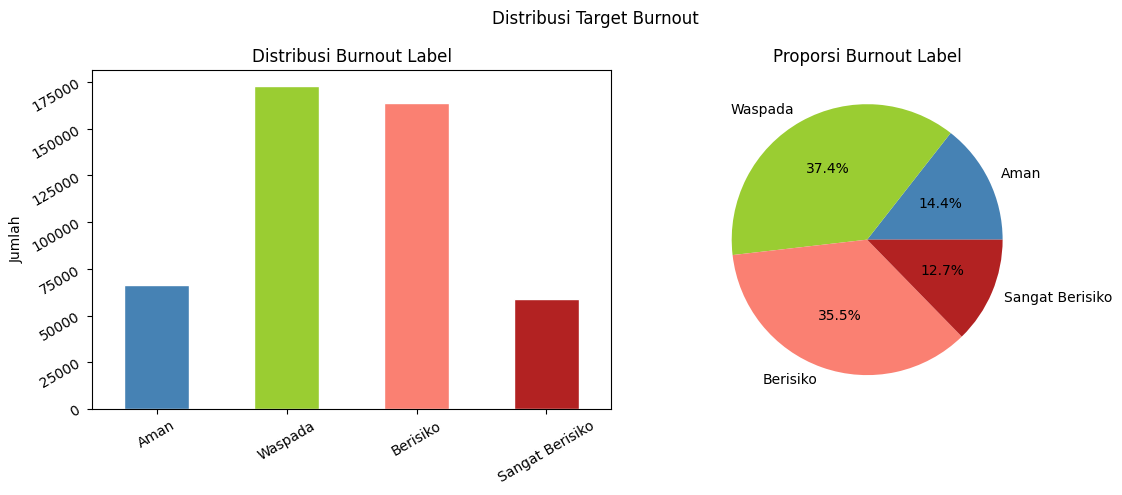

In [10]:
# Cek Distribusi Target
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

label_map = {0: 'Aman', 1: 'Waspada', 2: 'Berisiko', 3: 'Sangat Berisiko'}
colors = ['steelblue', 'yellowgreen', 'salmon', 'firebrick']

burnout_counts = df['burnout_label'].value_counts().sort_index()
burnout_counts.index = [label_map[i] for i in burnout_counts.index]

burnout_counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='white')
axes[0].set_title('Distribusi Burnout Label')
axes[0].set_ylabel('Jumlah')
axes[0].tick_params(rotation=30)

burnout_counts.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', colors=colors)
axes[1].set_title('Proporsi Burnout Label')
axes[1].set_ylabel('')

plt.suptitle('Distribusi Target Burnout')
plt.tight_layout()
plt.show()

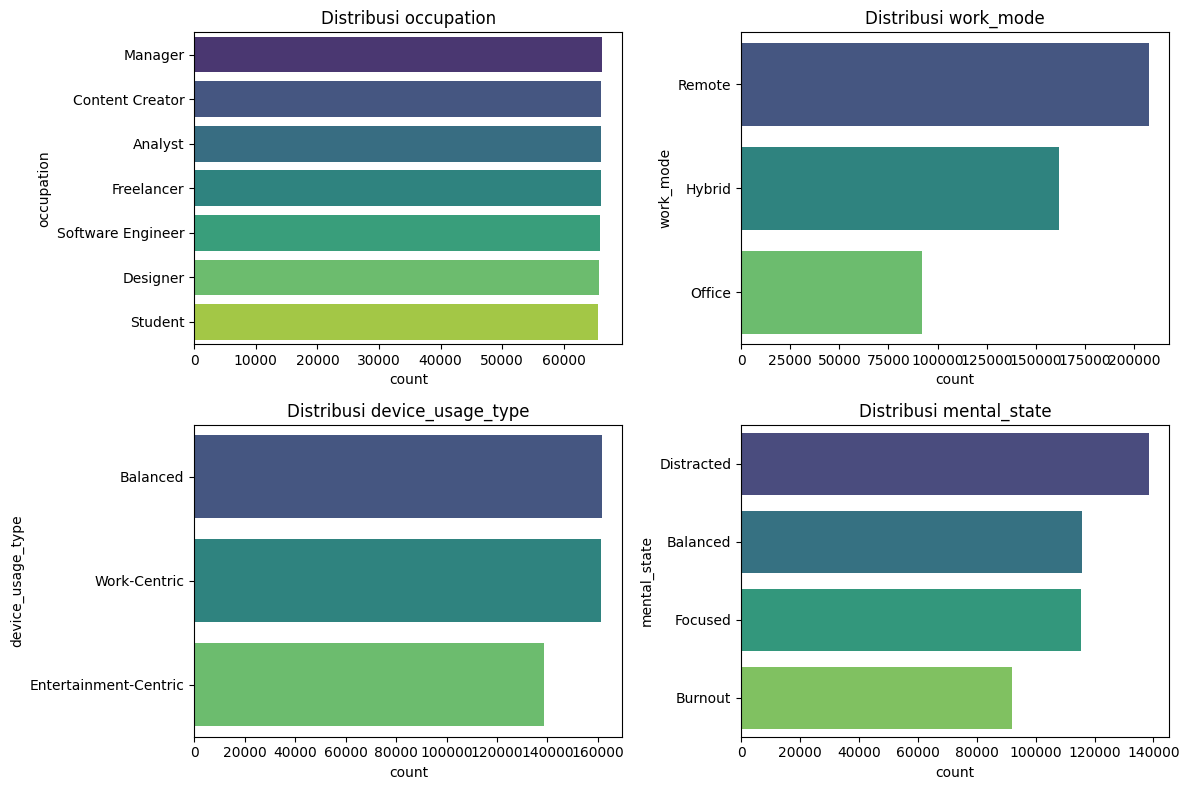

Distribusi Fitur Kategorik:

occupation:
occupation
Manager              66243
Content Creator      66051
Analyst              66046
Freelancer           66013
Software Engineer    65918
Designer             65751
Student              65558
Name: count, dtype: int64
Total unik: 7

work_mode:
work_mode
Remote    207502
Hybrid    161999
Office     92079
Name: count, dtype: int64
Total unik: 3

device_usage_type:
device_usage_type
Balanced                 161642
Work-Centric             161175
Entertainment-Centric    138763
Name: count, dtype: int64
Total unik: 3

mental_state:
mental_state
Distracted    138430
Balanced      115652
Focused       115423
Burnout        92075
Name: count, dtype: int64
Total unik: 4


In [11]:
# Distribusi Fitur Kategorik
cat_features = df.select_dtypes(include=[object]).drop(columns=['productivity_category'])
n_features = len(cat_features.columns)
n_rows = (n_features + 1) // 2

plt.figure(figsize=(12, n_rows * 4))
for i, column in enumerate(cat_features.columns, 1):
    plt.subplot(n_rows, 2, i)
    sns.countplot(y=df[column], palette='viridis',
                  order=df[column].value_counts().index)
    plt.title(f'Distribusi {column}')
plt.tight_layout()
plt.show()

# Print nilai exacts
print("Distribusi Fitur Kategorik:")
for col in cat_features.columns:
    print(f"\n{col}:")
    print(df[col].value_counts())
    print(f"Total unik: {df[col].nunique()}")

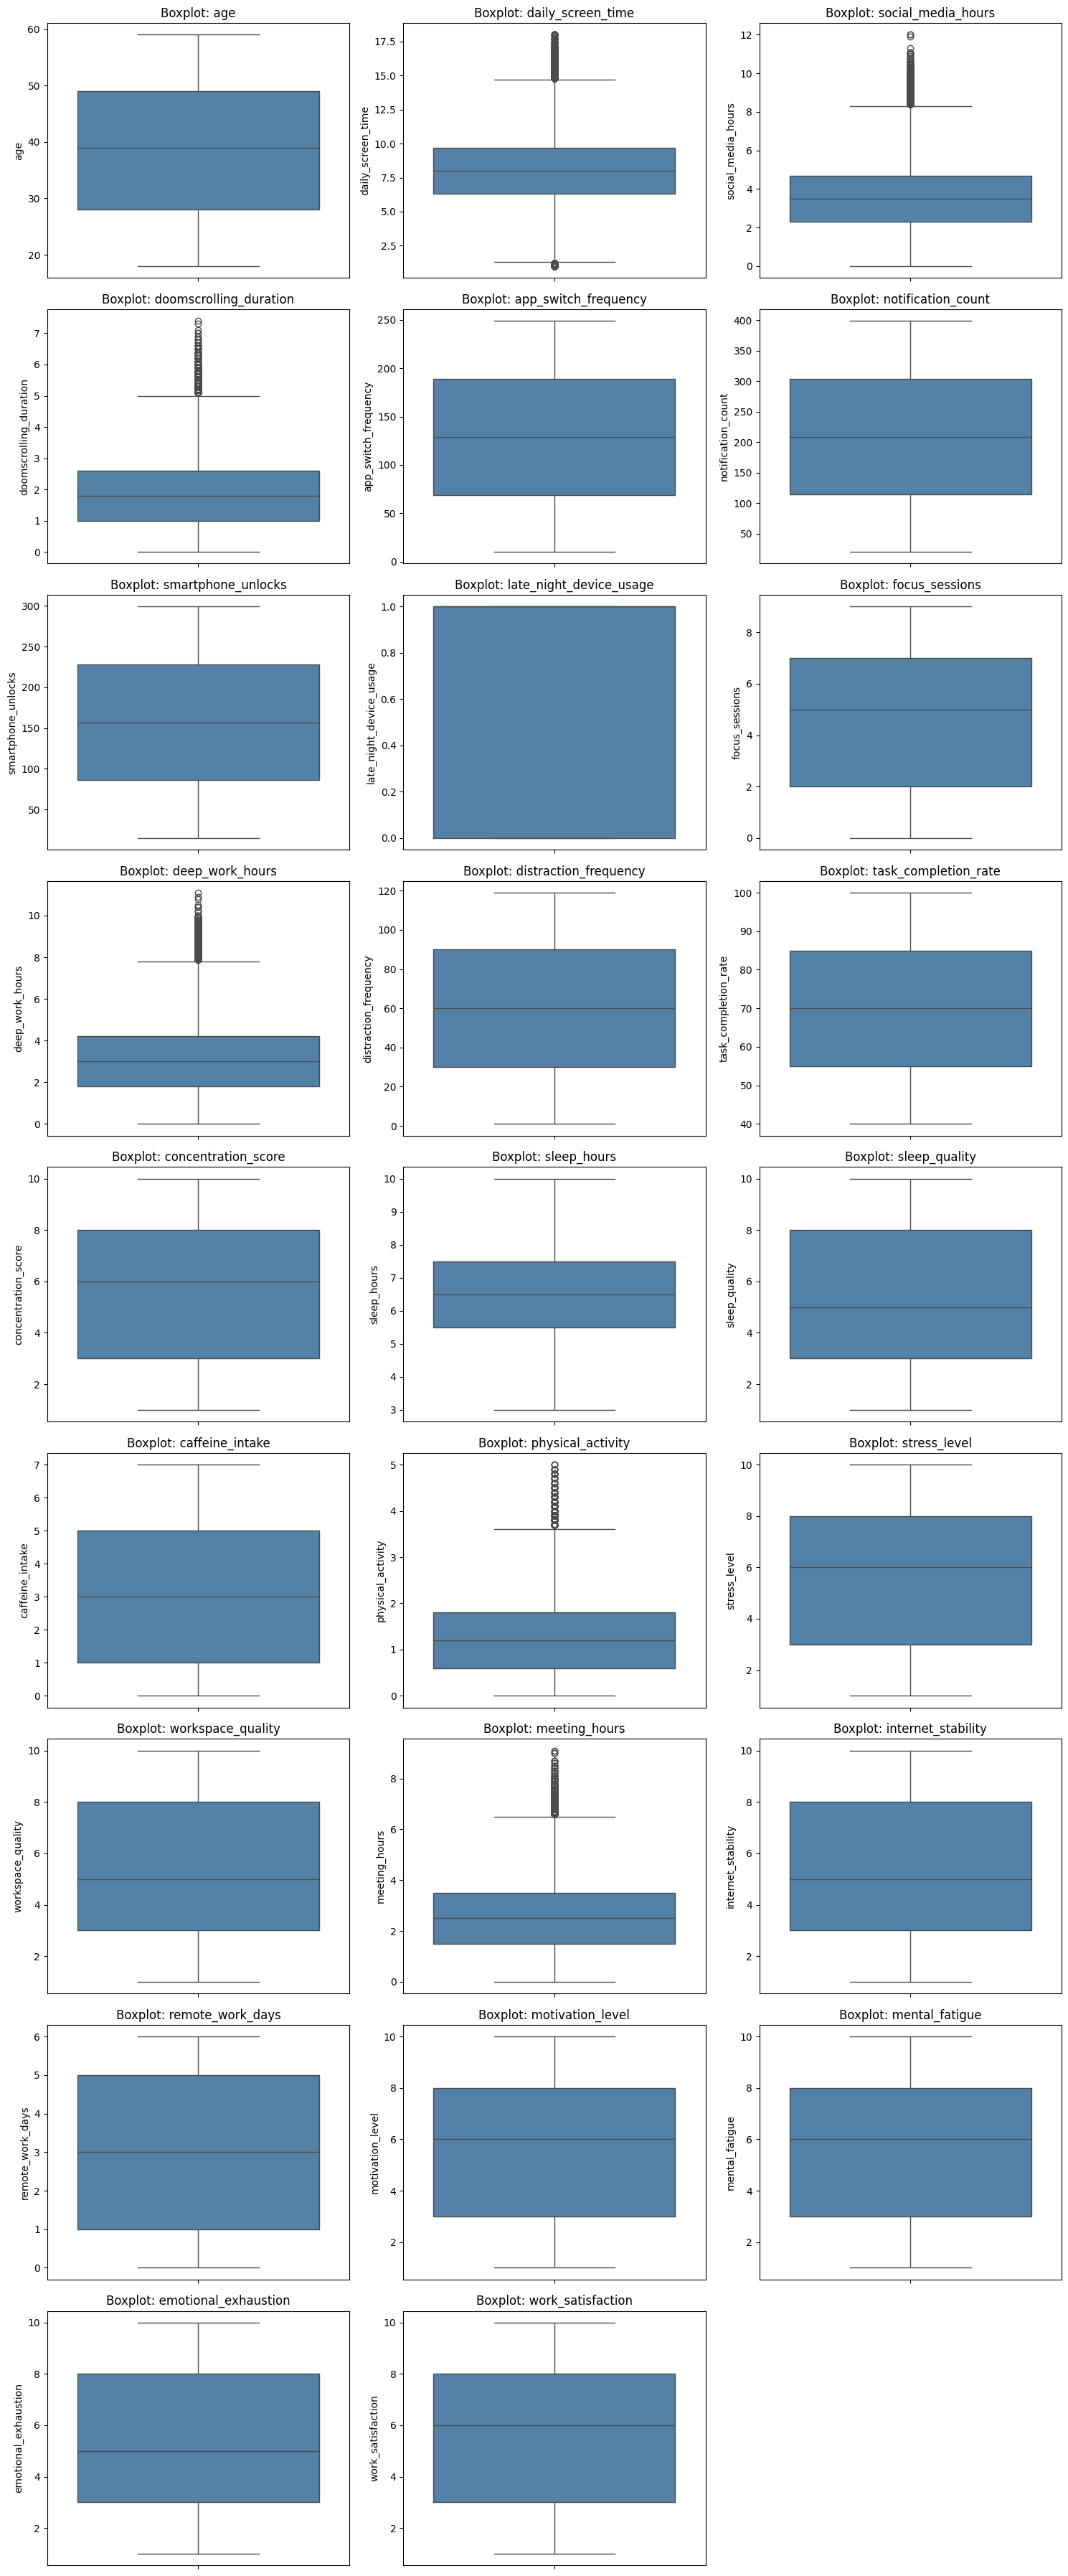

In [12]:
# Boxplot
num_features = df.select_dtypes(include=['int64', 'float64']).drop(
    columns=['user_id', 'burnout_risk', 'productivity_score',
             'burnout_label']).columns

n_features = len(num_features)
n_rows = (n_features + 2) // 3

plt.figure(figsize=(15, n_rows * 4))
for i, column in enumerate(num_features, 1):
    plt.subplot(n_rows, 3, i)
    sns.boxplot(y=df[column], color='steelblue')
    plt.title(f'Boxplot: {column}')
plt.tight_layout()
plt.show()

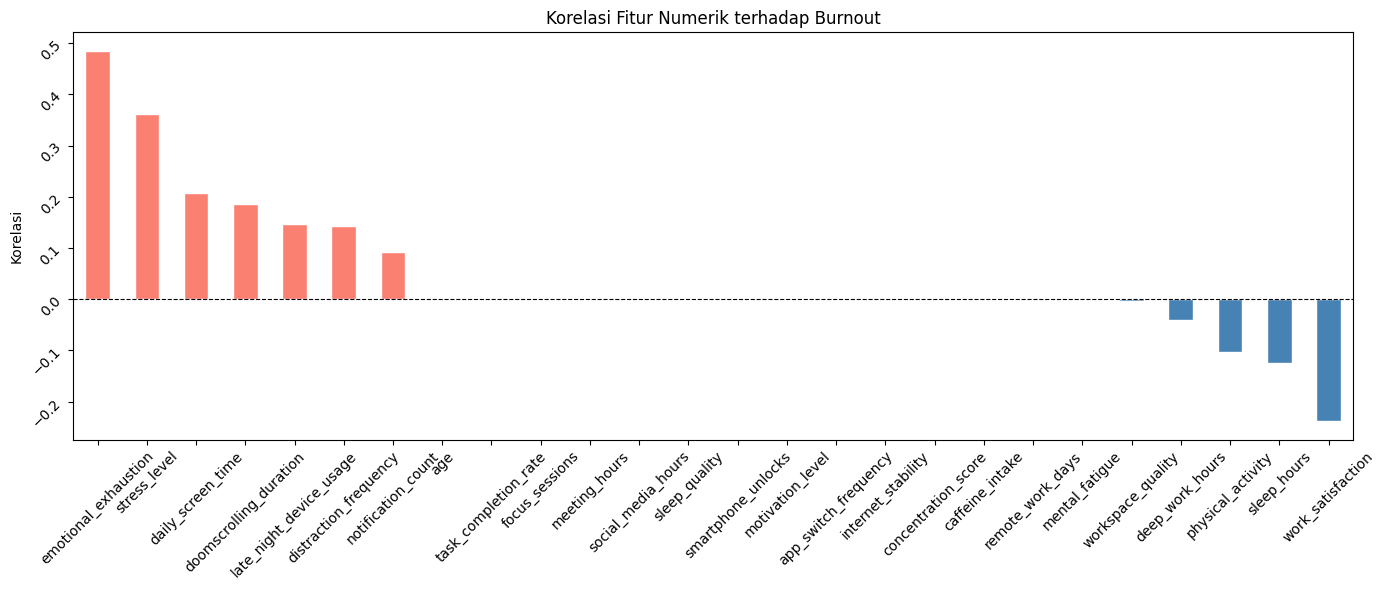

emotional_exhaustion       0.485237
stress_level               0.361444
daily_screen_time          0.207654
doomscrolling_duration     0.186271
late_night_device_usage    0.146670
distraction_frequency      0.143314
notification_count         0.092120
age                        0.002453
task_completion_rate       0.002206
focus_sessions             0.001965
meeting_hours              0.001500
social_media_hours         0.001274
sleep_quality              0.000501
smartphone_unlocks         0.000457
motivation_level          -0.000082
app_switch_frequency      -0.000240
internet_stability        -0.000398
concentration_score       -0.000613
caffeine_intake           -0.000750
remote_work_days          -0.000916
mental_fatigue            -0.001139
workspace_quality         -0.003782
deep_work_hours           -0.041163
physical_activity         -0.103362
sleep_hours               -0.123848
work_satisfaction         -0.237996
dtype: float64


In [13]:
# Korelasi Fitur Numerik terhadap Burnout
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_cols = [col for col in num_cols if col not in
            ['user_id', 'burnout_risk', 'productivity_score', 'burnout_label']]

correlations = df[num_cols].corrwith(df['burnout_label']).sort_values(ascending=False)

plt.figure(figsize=(14, 6))
correlations.plot(kind='bar',
    color=['salmon' if x > 0 else 'steelblue' for x in correlations],
    edgecolor='white')
plt.title('Korelasi Fitur Numerik terhadap Burnout')
plt.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
plt.ylabel('Korelasi')
plt.tick_params(rotation=45)
plt.tight_layout()
plt.show()

print(correlations)

In [14]:
# Fitur dan Target
drop_cols = ['user_id', 'burnout_risk', 'productivity_score',
             'productivity_category', 'burnout_label']

X = df.drop(columns=drop_cols)
y = df['burnout_label']

print(f"Shape X: {X.shape}")
print(f"Shape y: {y.shape}")
print(f"\nFitur ({len(X.columns)}):")
print(list(X.columns))

Shape X: (461580, 30)
Shape y: (461580,)

Fitur (30):
['age', 'occupation', 'work_mode', 'device_usage_type', 'daily_screen_time', 'social_media_hours', 'doomscrolling_duration', 'app_switch_frequency', 'notification_count', 'smartphone_unlocks', 'late_night_device_usage', 'focus_sessions', 'deep_work_hours', 'distraction_frequency', 'task_completion_rate', 'concentration_score', 'sleep_hours', 'sleep_quality', 'caffeine_intake', 'physical_activity', 'stress_level', 'workspace_quality', 'meeting_hours', 'internet_stability', 'remote_work_days', 'motivation_level', 'mental_fatigue', 'emotional_exhaustion', 'work_satisfaction', 'mental_state']


# Train Test Split

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train: {X_train.shape}")
print(f"X_test : {X_test.shape}")
print(f"\nDistribusi y_train:\n{y_train.value_counts(normalize=True).round(3)}")
print(f"\nDistribusi y_test:\n{y_test.value_counts(normalize=True).round(3)}")

X_train: (369264, 30)
X_test : (92316, 30)

Distribusi y_train:
burnout_label
1    0.374
2    0.355
0    0.144
3    0.127
Name: proportion, dtype: float64

Distribusi y_test:
burnout_label
1    0.374
2    0.355
0    0.144
3    0.127
Name: proportion, dtype: float64


# Preprocessing

In [16]:
# Encode Fitur Kategorik
from sklearn.preprocessing import OrdinalEncoder

cat_cols = X_train.select_dtypes(include='object').columns.tolist()
print(f"Kolom kategorik: {cat_cols}")

oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

X_train[cat_cols] = oe.fit_transform(X_train[cat_cols])
X_test[cat_cols] = oe.transform(X_test[cat_cols])

print("\nSample setelah encoding:")
X_train[cat_cols].head()

Kolom kategorik: ['occupation', 'work_mode', 'device_usage_type', 'mental_state']

Sample setelah encoding:


,occupation,work_mode,device_usage_type,mental_state
82749,3.0,2.0,2.0,3.0
22749,2.0,0.0,0.0,1.0
171255,2.0,0.0,1.0,1.0
355321,6.0,0.0,0.0,3.0
123935,3.0,0.0,2.0,3.0


In [17]:
# Scaling data
from sklearn.preprocessing import StandardScaler

# Hanya kolom numerik asli, exclude hasil encoding
cat_cols = ['occupation', 'work_mode', 'device_usage_type', 'mental_state']
num_cols = [col for col in X_train.columns if col not in cat_cols]

print(f"Kolom yang di-scaling ({len(num_cols)}): {num_cols}")

scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

print("\nSample setelah scaling:")
X_train.head()

Kolom yang di-scaling (26): ['age', 'daily_screen_time', 'social_media_hours', 'doomscrolling_duration', 'app_switch_frequency', 'notification_count', 'smartphone_unlocks', 'late_night_device_usage', 'focus_sessions', 'deep_work_hours', 'distraction_frequency', 'task_completion_rate', 'concentration_score', 'sleep_hours', 'sleep_quality', 'caffeine_intake', 'physical_activity', 'stress_level', 'workspace_quality', 'meeting_hours', 'internet_stability', 'remote_work_days', 'motivation_level', 'mental_fatigue', 'emotional_exhaustion', 'work_satisfaction']

Sample setelah scaling:


,age,occupation,work_mode,device_usage_type,daily_screen_time,social_media_hours,doomscrolling_duration,app_switch_frequency,notification_count,smartphone_unlocks,late_night_device_usage,focus_sessions,deep_work_hours,distraction_frequency,task_completion_rate,concentration_score,sleep_hours,sleep_quality,caffeine_intake,physical_activity,stress_level,workspace_quality,meeting_hours,internet_stability,remote_work_days,motivation_level,mental_fatigue,emotional_exhaustion,work_satisfaction,mental_state
82749,-0.289886,3.0,2.0,2.0,3.327898,1.695897,-1.621313,0.761570,-1.179868,-0.403384,0.732697,1.567893,0.853151,-0.232991,0.000275,0.173117,0.610249,-0.522216,-0.216324,-1.128546,-0.523333,1.568885,-0.16259,-0.520080,1.499860,-0.176231,0.171507,-0.173448,0.521455,3.0
22749,-0.537446,2.0,0.0,0.0,0.842823,0.672853,0.233407,-0.537258,0.598358,0.424134,0.732697,0.871425,-0.480585,-1.718305,-0.283377,-1.221472,0.949633,-1.567342,1.529464,0.077018,1.218234,-1.565279,1.15734,1.219837,-1.500939,-0.176231,-1.221275,0.522722,-0.174509,1.0
171255,-1.115086,2.0,0.0,1.0,-0.359632,-0.861713,-1.621313,1.237807,-0.249719,1.178636,0.732697,-0.869746,-0.190642,0.844590,-1.474717,-0.524177,0.135111,-0.522216,0.656570,-1.490216,-1.568274,-0.520558,1.29628,-1.216047,-1.500939,-1.567659,-0.524884,-0.173448,1.217420,1.0
355321,0.040193,6.0,0.0,0.0,0.802742,-0.407027,-0.208193,0.530667,0.443333,1.543717,0.732697,-1.566214,-0.132654,1.572685,1.191615,0.521764,-0.815164,-0.522216,1.529464,1.162027,-1.219960,1.568885,0.39317,-0.520080,-1.000805,-0.524088,-0.873080,-1.217702,-1.566439,3.0
123935,1.608072,3.0,0.0,2.0,-0.600123,0.047659,1.469887,-0.190904,0.926645,0.789216,0.732697,-1.217980,-0.944493,-0.087372,-1.361256,0.521764,0.135111,-1.567342,-0.652771,-1.490216,1.218234,-0.868798,-0.50994,1.567820,1.499860,-1.567659,-0.176689,-0.869617,-0.522492,3.0


# Modeling

In [18]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

lr = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lr))
print(f"ROC-AUC: {roc_auc_score(y_test, lr.predict_proba(X_test), multi_class='ovr', average='macro'):.4f}")

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.55      0.79      0.65     13318
           1       0.64      0.53      0.58     34517
           2       0.61      0.51      0.55     32762
           3       0.51      0.76      0.61     11719

    accuracy                           0.59     92316
   macro avg       0.58      0.64      0.60     92316
weighted avg       0.60      0.59      0.58     92316

ROC-AUC: 0.8567


In [19]:
# Naive Bayes
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)

print("=== Naive Bayes ===")
print(classification_report(y_test, y_pred_nb))
print(f"ROC-AUC: {roc_auc_score(y_test, nb.predict_proba(X_test), multi_class='ovr', average='macro'):.4f}")

=== Naive Bayes ===
              precision    recall  f1-score   support

           0       0.85      0.31      0.46     13318
           1       0.59      0.77      0.67     34517
           2       0.60      0.72      0.65     32762
           3       0.88      0.26      0.40     11719

    accuracy                           0.62     92316
   macro avg       0.73      0.51      0.54     92316
weighted avg       0.67      0.62      0.60     92316

ROC-AUC: 0.8599


In [20]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight='balanced')
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf))
print(f"ROC-AUC: {roc_auc_score(y_test, rf.predict_proba(X_test), multi_class='ovr', average='macro'):.4f}")

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.80      0.44      0.57     13318
           1       0.62      0.75      0.68     34517
           2       0.62      0.71      0.66     32762
           3       0.82      0.39      0.53     11719

    accuracy                           0.65     92316
   macro avg       0.71      0.57      0.61     92316
weighted avg       0.67      0.65      0.64     92316

ROC-AUC: 0.8705


In [21]:
# XGBoost
from xgboost import XGBClassifier

xgb = XGBClassifier(n_estimators=100, random_state=42, n_jobs=-1, eval_metric='logloss')
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print("=== XGBoost ===")
print(classification_report(y_test, y_pred_xgb))
print(f"ROC-AUC: {roc_auc_score(y_test, xgb.predict_proba(X_test), multi_class='ovr', average='macro'):.4f}")

=== XGBoost ===
              precision    recall  f1-score   support

           0       0.76      0.60      0.67     13318
           1       0.67      0.73      0.70     34517
           2       0.67      0.72      0.69     32762
           3       0.76      0.59      0.67     11719

    accuracy                           0.69     92316
   macro avg       0.71      0.66      0.68     92316
weighted avg       0.69      0.69      0.69     92316

ROC-AUC: 0.8963


In [22]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(n_estimators=100, random_state=42, n_jobs=-1)
lgbm.fit(X_train, y_train)

y_pred_lgbm = lgbm.predict(X_test)

print("=== LightGBM ===")
print(classification_report(y_test, y_pred_lgbm))
print(f"ROC-AUC: {roc_auc_score(y_test, lgbm.predict_proba(X_test), multi_class='ovr', average='macro'):.4f}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.009322 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1773
[LightGBM] [Info] Number of data points in the train set: 369264, number of used features: 30
[LightGBM] [Info] Start training from score -1.936082
[LightGBM] [Info] Start training from score -0.983780
[LightGBM] [Info] Start training from score -1.035941
[LightGBM] [Info] Start training from score -2.064006
=== LightGBM ===
              precision    recall  f1-score   support

           0       0.77      0.57      0.65     13318
           1       0.66      0.74      0.70     34517
           2       0.66      0.72      0.69     32762
           3       0.78      0.56      0.65     11719

    accuracy                           0.69     92316
   macro avg       0.72      0.65      0.67     92316
weighted avg       0.69      0.69

# Best Model

              Model  Accuracy  Macro F1  ROC-AUC
            XGBoost  0.688700  0.680988 0.896283
           LightGBM  0.685547  0.673769 0.894456
      Random Forest  0.645370  0.609172 0.870516
        Naive Bayes  0.619524  0.544609 0.859943
Logistic Regression  0.586951  0.596943 0.856742


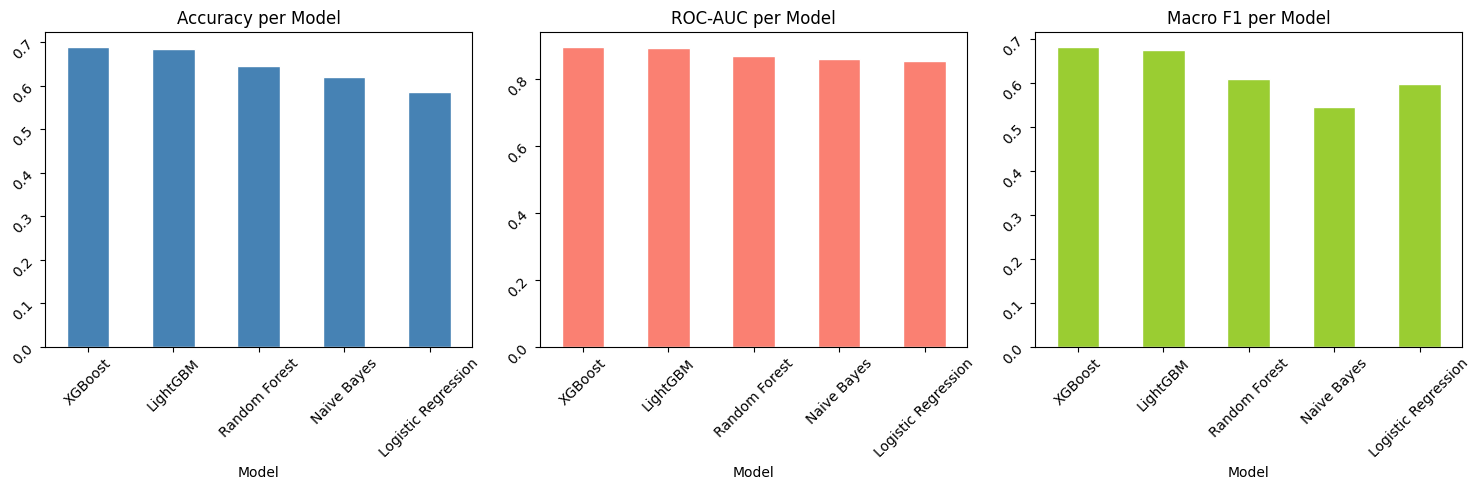

In [23]:
from sklearn.metrics import accuracy_score, f1_score

models = {
    'Logistic Regression': (lr, y_pred_lr),
    'Naive Bayes': (nb, y_pred_nb),
    'Random Forest': (rf, y_pred_rf),
    'XGBoost': (xgb, y_pred_xgb),
    'LightGBM': (lgbm, y_pred_lgbm)
}

results = []
for name, (model, y_pred) in models.items():
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Macro F1': f1_score(y_test, y_pred, average='macro'),
        'ROC-AUC': roc_auc_score(y_test, model.predict_proba(X_test), multi_class='ovr', average='macro')
    })

results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False)
print(results_df.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics = ['Accuracy', 'ROC-AUC', 'Macro F1']
colors = ['steelblue', 'salmon', 'yellowgreen']

for i, metric in enumerate(metrics):
    results_df.plot(x='Model', y=metric, kind='bar', ax=axes[i], color=colors[i], edgecolor='white', legend=False)
    axes[i].set_title(f'{metric} per Model')
    axes[i].tick_params(rotation=45)

plt.tight_layout()
plt.show()

# Tunning Model

In [24]:
import optuna

In [25]:
# Tuning Hyperparameter XGBoost
def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'random_state': 42,
        'n_jobs': -1,
        'eval_metric': 'mlogloss'
    }

    model = XGBClassifier(**params)
    model.fit(X_train, y_train)
    score = roc_auc_score(y_test, model.predict_proba(X_test),
                          multi_class='ovr', average='macro')
    return score

study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective_xgb, n_trials=50)

print(f"Best ROC-AUC XGBoost: {study_xgb.best_value:.4f}")
print(f"Best params: {study_xgb.best_params}")

[I 2026-06-14 12:26:54,120] A new study created in memory with name: no-name-a73bf8ce-fa1f-41ce-b591-de6e8e972f2a
[I 2026-06-14 12:27:16,821] Trial 0 finished with value: 0.891414944390512 and parameters: {'n_estimators': 332, 'max_depth': 5, 'learning_rate': 0.0416520069372956, 'subsample': 0.8656920342838432, 'colsample_bytree': 0.9103461068156324, 'min_child_weight': 2, 'gamma': 0.5129333823626486}. Best is trial 0 with value: 0.891414944390512.
[I 2026-06-14 12:27:30,723] Trial 1 finished with value: 0.8960589618813357 and parameters: {'n_estimators': 263, 'max_depth': 3, 'learning_rate': 0.13801051055968788, 'subsample': 0.6886239687474535, 'colsample_bytree': 0.653801252653512, 'min_child_weight': 2, 'gamma': 1.1601754692862003}. Best is trial 1 with value: 0.8960589618813357.
[I 2026-06-14 12:27:36,920] Trial 2 finished with value: 0.8109361103799898 and parameters: {'n_estimators': 109, 'max_depth': 3, 'learning_rate': 0.026392957384873742, 'subsample': 0.6505383790449865, 'col

Best ROC-AUC XGBoost: 0.8999
Best params: {'n_estimators': 480, 'max_depth': 3, 'learning_rate': 0.25747129207228486, 'subsample': 0.6136970981462548, 'colsample_bytree': 0.8300160374614467, 'min_child_weight': 10, 'gamma': 4.72152872295004}


In [26]:
# Tuning Hyperparameter LightGBM
def objective_lgbm(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 5),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 5),
        'random_state': 42,
        'n_jobs': -1,
        'verbose': -1
    }

    model = LGBMClassifier(**params)
    model.fit(X_train, y_train)
    score = roc_auc_score(y_test, model.predict_proba(X_test),
                          multi_class='ovr', average='macro')
    return score

study_lgbm = optuna.create_study(direction='maximize')
study_lgbm.optimize(objective_lgbm, n_trials=50)

print(f"Best ROC-AUC LightGBM: {study_lgbm.best_value:.4f}")
print(f"Best params: {study_lgbm.best_params}")

[I 2026-06-14 12:48:39,109] A new study created in memory with name: no-name-15011030-a91d-481e-9ce9-58cbf948e2db
[I 2026-06-14 12:49:08,396] Trial 0 finished with value: 0.8934411912577599 and parameters: {'n_estimators': 349, 'max_depth': 10, 'learning_rate': 0.16643612098708632, 'subsample': 0.9315725748837099, 'colsample_bytree': 0.907103236378483, 'min_child_samples': 60, 'num_leaves': 104, 'reg_alpha': 1.204954112494026, 'reg_lambda': 0.9067174928026628}. Best is trial 0 with value: 0.8934411912577599.
[I 2026-06-14 12:49:45,329] Trial 1 finished with value: 0.8972867708923584 and parameters: {'n_estimators': 429, 'max_depth': 7, 'learning_rate': 0.06162144233773892, 'subsample': 0.8921793044272965, 'colsample_bytree': 0.9008159543540802, 'min_child_samples': 65, 'num_leaves': 123, 'reg_alpha': 4.170857387496312, 'reg_lambda': 1.399748655445222}. Best is trial 1 with value: 0.8972867708923584.
[I 2026-06-14 12:50:01,254] Trial 2 finished with value: 0.8968733196735861 and paramet

Best ROC-AUC LightGBM: 0.8996
Best params: {'n_estimators': 419, 'max_depth': 3, 'learning_rate': 0.20291866176800463, 'subsample': 0.6964987979644757, 'colsample_bytree': 0.6568467888055822, 'min_child_samples': 83, 'num_leaves': 114, 'reg_alpha': 3.2366442539163245, 'reg_lambda': 3.943058095397097}


# Final Model

In [27]:
# Besok Model Final XGBoost
best_xgb = XGBClassifier(
    **study_xgb.best_params,
    random_state=42,
    n_jobs=-1,
    eval_metric='mlogloss'
)

best_xgb.fit(X_train, y_train)
y_pred_final = best_xgb.predict(X_test)

print("=== Final Model XGBoost (Tuned) ===")
print(classification_report(y_test, y_pred_final, 
      target_names=['Aman', 'Waspada', 'Berisiko', 'Sangat Berisiko']))
print(f"ROC-AUC: {roc_auc_score(y_test, best_xgb.predict_proba(X_test), multi_class='ovr', average='macro'):.4f}")

=== Final Model XGBoost (Tuned) ===
                 precision    recall  f1-score   support

           Aman       0.76      0.61      0.68     13318
        Waspada       0.68      0.73      0.70     34517
       Berisiko       0.68      0.72      0.70     32762
Sangat Berisiko       0.76      0.61      0.68     11719

       accuracy                           0.69     92316
      macro avg       0.72      0.67      0.69     92316
   weighted avg       0.70      0.69      0.69     92316

ROC-AUC: 0.8999


# Save Model

In [28]:
import joblib

joblib.dump(best_xgb, 'model_xgb.pkl')
joblib.dump(oe, 'ordinal_encoder.pkl')
joblib.dump(scaler, 'standard_scaler.pkl')

print("Model dan preprocessor disimpan!")

Model dan preprocessor disimpan!


# Clustering

In [29]:
# Fitur relevan untuk clustering
cluster_features = [
    'emotional_exhaustion', 'stress_level', 'daily_screen_time',
    'doomscrolling_duration', 'late_night_device_usage', 'distraction_frequency',
    'work_satisfaction', 'sleep_hours', 'physical_activity',
    'deep_work_hours', 'motivation_level', 'mental_state'
]

X_cluster = X_train[cluster_features].copy()

print(f"Shape data clustering: {X_cluster.shape}")
print(f"\nFitur clustering ({len(cluster_features)}):")
print(cluster_features)

Shape data clustering: (369264, 12)

Fitur clustering (12):
['emotional_exhaustion', 'stress_level', 'daily_screen_time', 'doomscrolling_duration', 'late_night_device_usage', 'distraction_frequency', 'work_satisfaction', 'sleep_hours', 'physical_activity', 'deep_work_hours', 'motivation_level', 'mental_state']


In [30]:
# Scaling mental_state untuk clustering
cluster_scaler = StandardScaler()
X_cluster_scaled = X_cluster.copy()
X_cluster_scaled['mental_state'] = cluster_scaler.fit_transform(X_cluster[['mental_state']])

print("Sample setelah scaling mental_state:")
print(X_cluster_scaled.describe().round(2))

Sample setelah scaling mental_state:
       emotional_exhaustion  stress_level  daily_screen_time  \
count             369264.00     369264.00          369264.00   
mean                  -0.00         -0.00              -0.00   
std                    1.00          1.00               1.00   
min                   -1.57         -1.57              -2.80   
25%                   -0.87         -0.87              -0.68   
50%                   -0.17         -0.18               0.00   
75%                    0.87          0.87               0.68   
max                    1.57          1.57               4.01   

       doomscrolling_duration  late_night_device_usage  distraction_frequency  \
count               369264.00                369264.00              369264.00   
mean                     0.00                    -0.00                   0.00   
std                      1.00                     1.00                   1.00   
min                     -1.62                    -1.36        

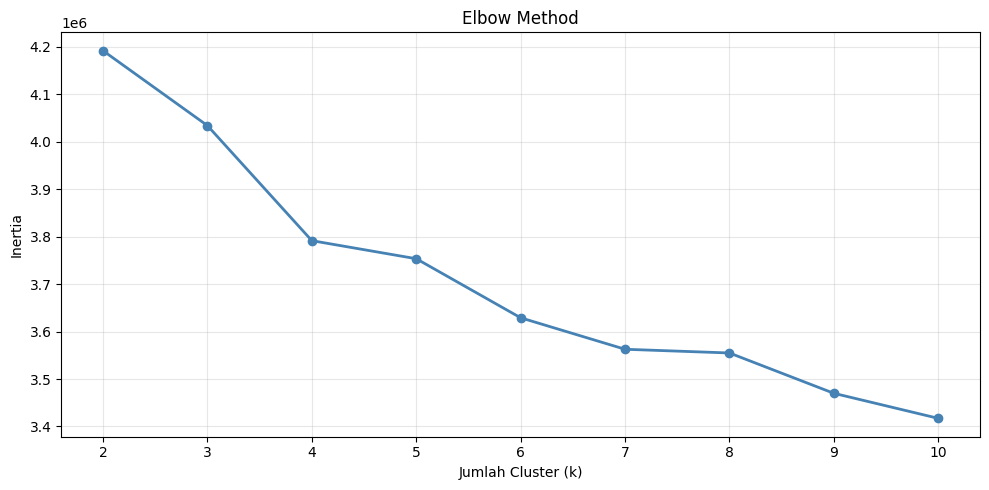

In [31]:
# Elbow Method
inertia = []
k_range = range(2, 11)

for k in k_range:
    kmeans = MiniBatchKMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(k_range, inertia, marker='o', color='steelblue', linewidth=2)
plt.title('Elbow Method')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Inertia')
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

k=2: Silhouette Score = 0.0558
k=3: Silhouette Score = 0.0477
k=4: Silhouette Score = 0.0553
k=5: Silhouette Score = 0.0538
k=6: Silhouette Score = 0.0519
k=7: Silhouette Score = 0.0507


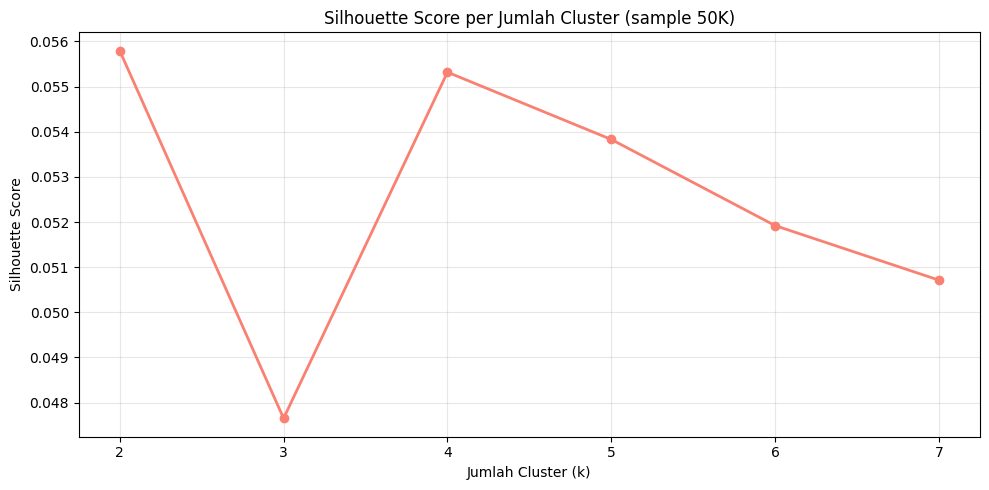

In [ ]:
# Silhouette Score
from sklearn.metrics import silhouette_score

silhouette_scores = []
k_range_sil = range(2, 8)

sample_idx = np.random.choice(len(X_cluster_scaled), 50000, replace=False)
X_sample = X_cluster_scaled.iloc[sample_idx]

for k in k_range_sil:
    kmeans = MiniBatchKMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster_scaled)
    score = silhouette_score(X_sample, kmeans.predict(X_sample))
    silhouette_scores.append(score)
    print(f"k={k}: Silhouette Score = {score:.4f}")

plt.figure(figsize=(10, 5))
plt.plot(k_range_sil, silhouette_scores, marker='o', color='salmon', linewidth=2)
plt.title('Silhouette Score per Jumlah Cluster (sample 50K)')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Silhouette Score')
plt.xticks(k_range_sil)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Final Clustering

In [33]:
kmeans_final = MiniBatchKMeans(n_clusters=4, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_cluster_scaled)

X_train['cluster'] = cluster_labels

print("Distribusi cluster:")
print(pd.Series(cluster_labels).value_counts().sort_index())

print("\nKarakteristik rata-rata per cluster:")
cluster_profile_df = X_cluster_scaled.copy()
cluster_profile_df['cluster'] = cluster_labels
cluster_profile = cluster_profile_df.groupby('cluster')[cluster_features].mean()
print(cluster_profile.T.round(2))

Distribusi cluster:
0     69084
1     77577
2    126359
3     96244
Name: count, dtype: int64

Karakteristik rata-rata per cluster:
cluster                     0     1     2     3
emotional_exhaustion     0.22 -0.07 -0.01 -0.09
stress_level            -0.49  0.32  0.02  0.07
daily_screen_time       -0.67  0.32  0.02  0.19
doomscrolling_duration   0.35 -0.14 -0.01 -0.12
late_night_device_usage  0.66  0.72 -1.36  0.73
distraction_frequency    0.37  0.06 -0.01 -0.30
work_satisfaction        0.27 -0.20 -0.01 -0.03
sleep_hours              0.37 -0.05 -0.01 -0.21
physical_activity       -0.05  0.07 -0.00 -0.01
deep_work_hours          0.07  0.08 -0.00 -0.11
motivation_level        -0.46  0.37  0.01  0.02
mental_state            -0.18 -0.89  0.01  0.84


# Validasi dan Interpretasi Cluster

          Aman  Waspada  Berisiko  Sangat Berisiko
cluster                                           
0        0.139    0.385     0.359            0.117
1        0.051    0.269     0.428            0.252
2        0.194    0.407     0.315            0.084
3        0.158    0.406     0.346            0.090


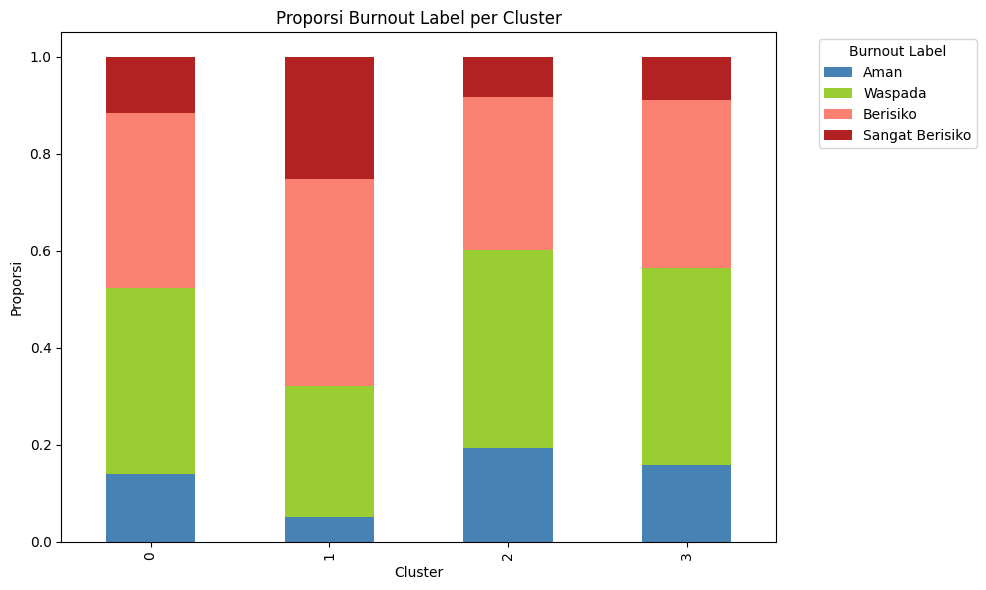

In [ ]:
# Validasi cluster dengan distribusi burnout_label
cross_tab = pd.crosstab(X_train['cluster'], y_train, normalize='index')
cross_tab.columns = ['Aman', 'Waspada', 'Berisiko', 'Sangat Berisiko']
print(cross_tab.round(3))

cross_tab.plot(kind='bar', stacked=True, figsize=(10, 6), 
               color=['steelblue', 'yellowgreen', 'salmon', 'firebrick'])
plt.title('Proporsi Burnout Label per Cluster')
plt.ylabel('Proporsi')
plt.xlabel('Cluster')
plt.legend(title='Burnout Label', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

Variance explained by PC1: 8.39%
Variance explained by PC2: 8.39%
Total variance explained: 16.78%


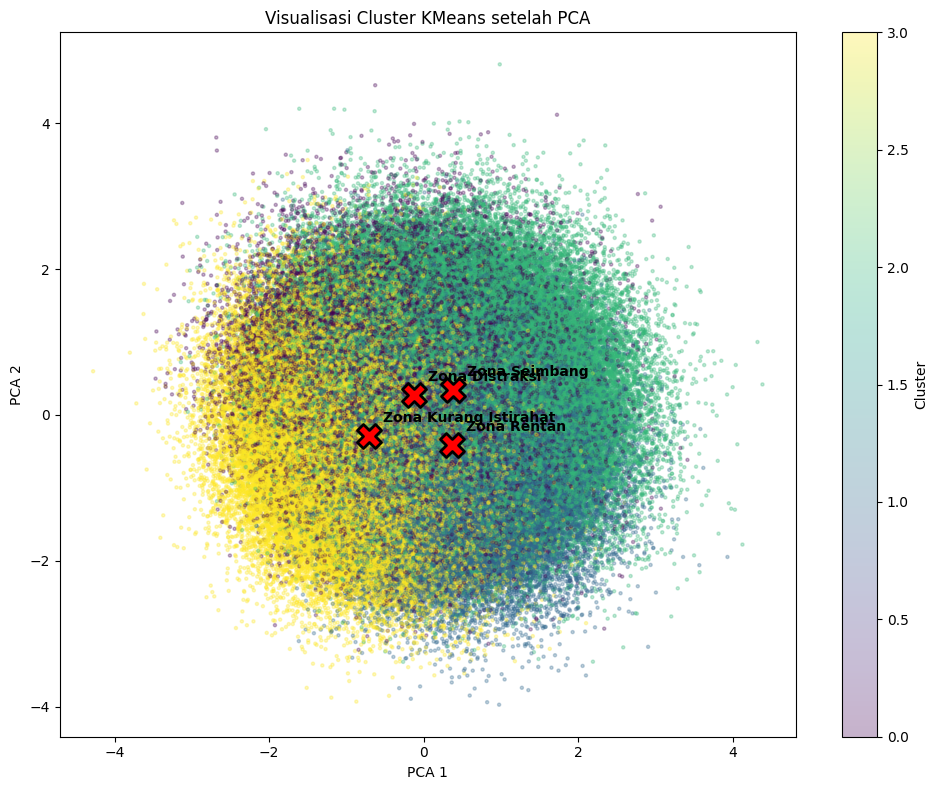

In [35]:
# Visualisasi Cluster dengan PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_cluster_scaled)

print(f"Variance explained by PC1: {pca.explained_variance_ratio_[0]*100:.2f}%")
print(f"Variance explained by PC2: {pca.explained_variance_ratio_[1]*100:.2f}%")
print(f"Total variance explained: {sum(pca.explained_variance_ratio_)*100:.2f}%")

cluster_names = {
    0: 'Zona Distraksi',
    1: 'Zona Rentan',
    2: 'Zona Seimbang',
    3: 'Zona Kurang Istirahat'
}

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, 
                       cmap='viridis', alpha=0.3, s=5)

centers_pca = pca.transform(kmeans_final.cluster_centers_)
plt.scatter(centers_pca[:, 0], centers_pca[:, 1], 
            c='red', marker='X', s=300, edgecolors='black', linewidths=2)

for i, (x, y) in enumerate(centers_pca):
    plt.annotate(cluster_names[i], (x, y), fontsize=10, fontweight='bold',
                 xytext=(10, 10), textcoords='offset points')

plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('Visualisasi Cluster KMeans setelah PCA')
plt.colorbar(scatter, label='Cluster')
plt.tight_layout()
plt.show()

# Save Model Clustering

In [36]:
import joblib

joblib.dump(kmeans_final, 'kmeans_model.pkl')
joblib.dump(cluster_scaler, 'cluster_scaler.pkl')

print("Model clustering dan scaler disimpan!")

Model clustering dan scaler disimpan!


# Rekomendasi berdasarkan clustering

In [37]:
recommendations = {
    0: {  # Zona Distraksi
        'nama': 'Zona Distraksi',
        'deskripsi': 'Kondisimu cukup stabil dari segi kepuasan kerja dan tidur, tapi kebiasaan digital seperti doomscrolling dan begadang main HP membuat motivasi dan fokusmu menurun.',
        'rekomendasi': [
            'Coba teknik Pomodoro (25 menit fokus, 5 menit istirahat) untuk membangun ritme kerja',
            'Set batas waktu harian untuk media sosial menggunakan fitur screen time di HP',
            'Mulai hari dengan satu target kecil yang jelas untuk membangun momentum'
        ]
    },
    1: {  # Zona Rentan
        'nama': 'Zona Rentan',
        'deskripsi': 'Kamu termotivasi dan terus berusaha, tapi tingkat stres yang tinggi dan kepuasan kerja yang rendah membuatmu paling rentan terhadap burnout.',
        'rekomendasi': [
            'Evaluasi ulang beban kerja, apakah realistis dengan waktu yang tersedia',
            'Sisipkan jeda singkat (5-10 menit) setiap 1-2 jam kerja, bukan hanya saat lelah',
            'Bicarakan dengan atasan, mentor, atau teman tentang tekanan yang dirasakan'
        ]
    },
    2: {  # Zona Seimbang
        'nama': 'Zona Seimbang',
        'deskripsi': 'Kondisimu secara umum sehat dan seimbang. Pertahankan kebiasaan baik yang sudah berjalan.',
        'rekomendasi': [
            'Pertahankan rutinitas tidur dan kerja yang sudah berjalan baik',
            'Sesekali evaluasi diri untuk memastikan tidak ada perubahan kebiasaan ke arah negatif',
            'Bagikan kebiasaan baikmu ke teman yang mungkin membutuhkan'
        ]
    },
    3: {  # Zona Kurang Istirahat
        'nama': 'Zona Kurang Istirahat',
        'deskripsi': 'Banyak aspek kondisimu cukup baik, tapi kebiasaan begadang dengan gadget mengurangi kualitas tidur dan kemampuan fokusmu.',
        'rekomendasi': [
            'Terapkan digital sunset, matikan layar 30-60 menit sebelum tidur',
            'Letakkan HP di luar jangkauan tempat tidur saat malam',
            'Coba aktivitas relaksasi sebelum tidur seperti membaca atau journaling'
        ]
    }
}

# Test print
for cluster_id, info in recommendations.items():
    print(f"=== {info['nama']} ===")
    print(f"Deskripsi: {info['deskripsi']}")
    print("Rekomendasi:")
    for rec in info['rekomendasi']:
        print(f"  - {rec}")
    print()

=== Zona Distraksi ===
Deskripsi: Kondisimu cukup stabil dari segi kepuasan kerja dan tidur, tapi kebiasaan digital seperti doomscrolling dan begadang main HP membuat motivasi dan fokusmu menurun.
Rekomendasi:
  - Coba teknik Pomodoro (25 menit fokus, 5 menit istirahat) untuk membangun ritme kerja
  - Set batas waktu harian untuk media sosial menggunakan fitur screen time di HP
  - Mulai hari dengan satu target kecil yang jelas untuk membangun momentum

=== Zona Rentan ===
Deskripsi: Kamu termotivasi dan terus berusaha, tapi tingkat stres yang tinggi dan kepuasan kerja yang rendah membuatmu paling rentan terhadap burnout.
Rekomendasi:
  - Evaluasi ulang beban kerja, apakah realistis dengan waktu yang tersedia
  - Sisipkan jeda singkat (5-10 menit) setiap 1-2 jam kerja, bukan hanya saat lelah
  - Bicarakan dengan atasan, mentor, atau teman tentang tekanan yang dirasakan

=== Zona Seimbang ===
Deskripsi: Kondisimu secara umum sehat dan seimbang. Pertahankan kebiasaan baik yang sudah berj

# Save Recommendation

In [38]:
import json

with open('recommendations.json', 'w', encoding='utf-8') as f:
    json.dump(recommendations, f, ensure_ascii=False, indent=2)

print("Recommendations berhasil disimpan ke recommendations.json")

Recommendations berhasil disimpan ke recommendations.json


# Setup SHAP Explainer

In [44]:
import shap

explainer = shap.TreeExplainer(best_xgb)

# Final Prediction Pipeline

In [45]:
def predict_burnout(user_input, top_n=5):
    input_df = pd.DataFrame([user_input])
    
    cat_cols = ['occupation', 'work_mode', 'device_usage_type', 'mental_state']
    input_df[cat_cols] = oe.transform(input_df[cat_cols])
    
    num_cols = [col for col in input_df.columns if col not in cat_cols]
    input_df[num_cols] = scaler.transform(input_df[num_cols])
    
    burnout_pred = best_xgb.predict(input_df)[0]
    burnout_proba = best_xgb.predict_proba(input_df)[0]
    
    label_map = {0: 'Aman', 1: 'Waspada', 2: 'Berisiko', 3: 'Sangat Berisiko'}
    
    input_cluster = input_df[cluster_features].copy()
    input_cluster['mental_state'] = cluster_scaler.transform(input_cluster[['mental_state']])
    cluster_pred = kmeans_final.predict(input_cluster)[0]
    
    shap_result = explainer(input_df)
    shap_for_pred_class = shap_result.values[0, :, burnout_pred]
    
    feature_contributions = pd.Series(shap_for_pred_class, index=input_df.columns)
    feature_contributions = feature_contributions.sort_values(key=abs, ascending=False)
    
    top_features = []
    for feat, val in feature_contributions.head(top_n).items():
        top_features.append({
            'fitur': feat,
            'kontribusi': float(val),
            'arah': 'meningkatkan risiko' if val > 0 else 'menurunkan risiko'
        })
    
    hasil = {
        'burnout_label': label_map[burnout_pred],
        'burnout_confidence': float(burnout_proba[burnout_pred]),
        'cluster': recommendations[cluster_pred]['nama'],
        'cluster_deskripsi': recommendations[cluster_pred]['deskripsi'],
        'rekomendasi': recommendations[cluster_pred]['rekomendasi'],
        'top_features': top_features
    }
    
    return hasil

In [46]:
sample_input = {
    'age': 25,
    'occupation': 'Software Engineer',
    'work_mode': 'Remote',
    'device_usage_type': 'Work-Centric',
    'daily_screen_time': 10.5,
    'social_media_hours': 3.0,
    'doomscrolling_duration': 2.0,
    'app_switch_frequency': 150,
    'notification_count': 250,
    'smartphone_unlocks': 180,
    'late_night_device_usage': 1,
    'focus_sessions': 5,
    'deep_work_hours': 4.5,
    'distraction_frequency': 60,
    'task_completion_rate': 70,
    'concentration_score': 6,
    'sleep_hours': 5.5,
    'sleep_quality': 4,
    'caffeine_intake': 4,
    'physical_activity': 2.0,
    'stress_level': 8,
    'workspace_quality': 6,
    'meeting_hours': 3.0,
    'internet_stability': 7,
    'remote_work_days': 4,
    'motivation_level': 7.0,
    'mental_fatigue': 7,
    'emotional_exhaustion': 8,
    'work_satisfaction': 3,
    'mental_state': 'Burnout'
}

In [47]:
result = predict_burnout(sample_input)

print(f"Burnout Label: {result['burnout_label']}")
print(f"Confidence: {result['burnout_confidence']:.2%}")
print(f"\nCluster: {result['cluster']}")
print(f"Deskripsi: {result['cluster_deskripsi']}")

print(f"\nTop Fitur Penyebab:")
for f in result['top_features']:
    print(f"  - {f['fitur']}: {f['kontribusi']:.4f} ({f['arah']})")

print(f"\nRekomendasi:")
for rec in result['rekomendasi']:
    print(f"  - {rec}")

Burnout Label: Sangat Berisiko
Confidence: 97.02%

Cluster: Zona Rentan
Deskripsi: Kamu termotivasi dan terus berusaha, tapi tingkat stres yang tinggi dan kepuasan kerja yang rendah membuatmu paling rentan terhadap burnout.

Top Fitur Penyebab:
  - mental_state: 2.2101 (meningkatkan risiko)
  - emotional_exhaustion: 1.0374 (meningkatkan risiko)
  - stress_level: 0.9025 (meningkatkan risiko)
  - daily_screen_time: 0.7365 (meningkatkan risiko)
  - work_satisfaction: 0.7310 (meningkatkan risiko)

Rekomendasi:
  - Evaluasi ulang beban kerja, apakah realistis dengan waktu yang tersedia
  - Sisipkan jeda singkat (5-10 menit) setiap 1-2 jam kerja, bukan hanya saat lelah
  - Bicarakan dengan atasan, mentor, atau teman tentang tekanan yang dirasakan
